## 인공 신경망

In [19]:
from tensorflow import keras
(train_input, train_target), (test_input, test_target) = \
    keras.datasets.mnist.load_data()

In [20]:
# Data 확인
print(train_input.shape, train_target.shape)
print(test_input.shape, test_target.shape)

(60000, 28, 28) (60000,)
(10000, 28, 28) (10000,)


In [21]:
train_target[:10]

array([5, 0, 4, 1, 9, 2, 1, 3, 1, 4], dtype=uint8)

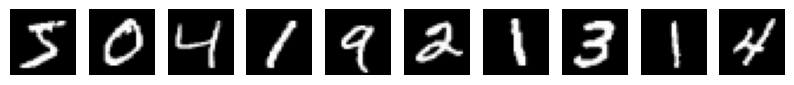

In [22]:
# train_input 의 모양 10개만 출력해보기
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 10, figsize=(10, 10))
for i in range(10):
    axs[i].imshow(train_input[i], cmap='gray')
    axs[i].axis('off')

plt.show()

###

#### 인공신경망 확인
: 몇번의 Epoch가 최대 인지 확인하기

In [23]:
# 데이터 표준화 및 2차 행렬로 만들기
train_scaled = train_input / 255.0
train_scaled = train_scaled.reshape(-1, 28*28)
train_scaled.shape

# ⚠️ 추가: Test 데이터도 Train 데이터와 똑같이 2차원(784)으로 전처리해야 합니다.
test_scaled = test_input / 255.0
test_scaled = test_scaled.reshape(-1, 28*28)

In [24]:
from sklearn.model_selection import cross_validate
from sklearn.linear_model import SGDClassifier
import numpy as np

sc = SGDClassifier(
    loss='log_loss',
    max_iter=5,
    random_state=42
)

scores = cross_validate(
    sc,
    train_scaled,
    train_target,
    n_jobs=-1
)

print("평균 : ", np.mean(scores['test_score']))

평균 :  0.8914166666666666


In [25]:
# train Data 를 훈련 데이터와 검증 데이터로 나누기
from sklearn.model_selection import train_test_split

train_scaled, val_scared, train_target, val_target = \
    train_test_split(
        train_scaled,
        train_target,
        test_size=0.2,
        random_state=42
    )

In [26]:
print(train_scaled.shape, train_target.shape)
print(train_target.shape, train_target.shape)

(48000, 784) (48000,)
(48000,) (48000,)


In [27]:
from tensorflow.keras.layers import Input
model = keras.Sequential()
model.add(Input(shape=(784,)))
model.add(keras.layers.Dense(10,activation="softmax" )) #sigmoid

In [28]:
# 손실함수
model.compile(
    loss="sparse_categorical_crossentropy",
    metrics = ['accuracy']
)

In [29]:
# 모델 훈련
model.fit(train_scaled, train_target, epochs=10)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 907us/step - accuracy: 0.8744 - loss: 0.4699
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 909us/step - accuracy: 0.9133 - loss: 0.3112
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 870us/step - accuracy: 0.9187 - loss: 0.2945
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 878us/step - accuracy: 0.9218 - loss: 0.2863
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 866us/step - accuracy: 0.9238 - loss: 0.2816
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 884us/step - accuracy: 0.9255 - loss: 0.2789
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 887us/step - accuracy: 0.9257 - loss: 0.2757
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 927us/step - accuracy: 0.9270 - loss: 0.2744
Epoch 9/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 912us/step - accuracy: 0.9276 - loss: 0.2727
Epoch 10/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 903us/step - accuracy: 0.9287 - loss: 0.2712


In [34]:
# 데이터 불러오기
from tensorflow import keras
(train_input, train_target), (test_input, test_target) = \
    keras.datasets.fashion_mnist.load_data()

# 데이터 표준화 및 2차 행렬로 만들기
train_scaled = train_input / 255.0
train_scaled = train_scaled.reshape(-1, 28*28)

# ⚠️ 추가: Test 데이터도 Train 데이터와 똑같이 2차원(784)으로 전처리해야 합니다.
test_scaled = test_input / 255.0
test_scaled = test_scaled.reshape(-1, 28*28)

from sklearn.model_selection import cross_validate
from sklearn.linear_model import SGDClassifier
from tensorflow.keras.callbacks import ModelCheckpoint

sc = SGDClassifier(
    loss='log_loss',
    max_iter=5,
    random_state=42
)

scores = cross_validate(
    sc,
    train_scaled,
    train_target,
    n_jobs=-1
)

# train Data 를 훈련 데이터와 검증 데이터로 나누기
from sklearn.model_selection import train_test_split

# 오타 수정: val_scared -> val_scaled
train_scaled, val_scaled, train_target, val_target = \
    train_test_split(
        train_scaled,
        train_target,
        test_size=0.2,
        random_state=42
    )

from tensorflow.keras.layers import Input
model = keras.Sequential()
model.add(Input(shape=(784,)))
model.add(keras.layers.Dense(10, activation="softmax"))

# 손실함수
model.compile(
    loss="sparse_categorical_crossentropy",
    metrics=['accuracy']
)

# 1. 저장할 파일명과 조건 설정
checkpoint_cb = ModelCheckpoint(
    filepath='best_model.keras',     # 가장 성능이 좋은 모델을 저장할 파일명
    monitor='val_accuracy',          # 검증 정확도(val_accuracy)를 기준으로 감시
    save_best_only=True,             # 최고 점수가 갱신될 때만 저장 (이전 모델 덮어쓰기)
    mode='max',                      # 정확도는 높을수록 좋으므로 'max' 설정
    verbose=1                        # 저장될 때마다 안내 로그 출력
)

# [수정] 1. 검증 데이터를 지정하고, 2. 학습 기록을 history 변수에 저장합니다.
history = model.fit(
    train_scaled, 
    train_target, 
    epochs=20,
    validation_data=(val_scaled, val_target), # 검증 데이터 추가
    callbacks=[checkpoint_cb]         # 👈 콜백 추가
)

# 3. 훈련이 끝난 후, 저장된 '가장 베스트 모델'을 불러와서 테스트 데이터 평가
best_model = keras.models.load_model('best_model.keras')
test_loss, test_acc = best_model.evaluate(test_scaled, test_target, verbose=0)

# [추가] 4. 마지막 에포크(5번째)의 Train, Valid 정확도 추출
final_train_acc = history.history['accuracy'][-1]
final_valid_acc = history.history['val_accuracy'][-1]

# [추가] 5. 세 가지 데이터 정확도 일괄 출력
print("\n" + "=" * 40)
print(f"🥇 Train Accuracy (훈련) : {final_train_acc:.4f}")
print(f"🥈 Valid Accuracy (검증) : {final_valid_acc:.4f}")
print(f"🥉 Test  Accuracy (테스트): {test_acc:.4f}")
print("=" * 40)

Epoch 1/20
1457/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 901us/step - accuracy: 0.7893 - loss: 0.6097
Epoch 1: val_accuracy improved from None to 0.81500, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7906 - loss: 0.6059 - val_accuracy: 0.8150 - val_loss: 0.5267
Epoch 2/20
1449/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 907us/step - accuracy: 0.8388 - loss: 0.4761
Epoch 2: val_accuracy improved from 0.81500 to 0.83592, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8390 - loss: 0.4751 - val_accuracy: 0.8359 - val_loss: 0.4854
Epoch 3/20
1488/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 916us/step - accuracy: 0.8474 - loss: 0.4506
Epoch 3: val_accuracy improved from 0.83592 to 0.84392, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8472 - loss: 0.

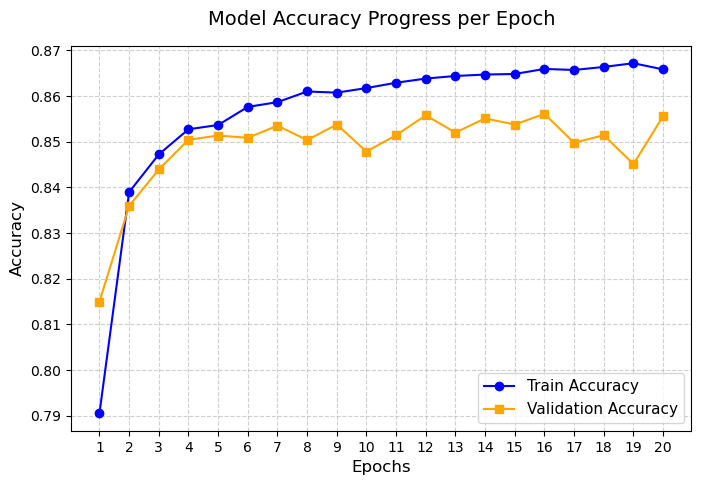

In [35]:
import matplotlib.pyplot as plt

# 1. history 객체에서 에포크별 train, valid 정확도 리스트 추출
train_acc_list = history.history['accuracy']
valid_acc_list = history.history['val_accuracy']

# 2. 에포크 수를 기준으로 x축 설정 (1부터 시작)
epochs_range = range(1, len(train_acc_list) + 1)

# 3. 그래프 그리기
plt.figure(figsize=(8, 5)) # 그래프 크기 설정
plt.plot(epochs_range, train_acc_list, label='Train Accuracy', marker='o', color='blue')
plt.plot(epochs_range, valid_acc_list, label='Validation Accuracy', marker='s', color='orange')

# 4. 그래프 꾸미기 (제목, 축 레이블, 범례 등)
plt.title('Model Accuracy Progress per Epoch', fontsize=14, pad=15)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.xticks(epochs_range) # x축 눈금을 에포크 정수로 고정
plt.grid(True, linestyle='--', alpha=0.6) # 배경 격자 추가
plt.legend(loc='lower right', fontsize=11) # 범례 위치 설정

# 5. 화면에 그래프 출력
plt.show()
